# Chapter 10 notebook — Physical AI control loop

Visualizes the toy simulation from `project_06_physical_ai_simulation` under three regimes:
1. Baseline: perfect perception, default safety.
2. Noisy perception: `noise_std = 0.3`.
3. Human override: safety gate is forced into stop mode.

Each regime produces a trajectory plot + a summary of safety blocks. Use this notebook to feel the effect of each layer in the loop.

In [1]:
import sys, math, json
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
sys.path.insert(0, str(Path('../projects/project_06_physical_ai_simulation').resolve()))

import matplotlib.pyplot as plt
from world import Robot, World
from src.physical_ai import (
    GridWorldPerception, GoalSeekDecision, DiffDriveController, SafetyGate,
)

In [2]:
def run(perception, decision, controller, safety, *, dt=0.05, max_steps=600):
    world = World(size=(10.0, 10.0),
                  obstacles=[(4.0, 4.0), (6.0, 3.0), (3.5, 6.5)],
                  goal=(8.0, 8.0))
    robot = Robot(1.0, 1.0, 0.0)
    trajectory = [(robot.x, robot.y)]
    blocks: dict[str, int] = {}
    reached = False
    for _ in range(max_steps):
        obs = perception.observe(robot.pose, world.goal, world.obstacles)
        action = decision.decide(obs)
        cmd = controller.control(action)
        verdict = safety.gate(cmd, obs)
        robot.step(verdict.command.v_left, verdict.command.v_right, dt)
        trajectory.append((robot.x, robot.y))
        if verdict.blocked:
            blocks[verdict.reason] = blocks.get(verdict.reason, 0) + 1
        if obs.distance_to_goal <= decision.goal_tolerance:
            reached = True
            break
    return trajectory, blocks, reached

## Run 1 — Baseline

In [3]:
perception = GridWorldPerception()
decision   = GoalSeekDecision(obstacle_safety_dist=0.6, max_forward=0.7, turn_gain=1.5)
controller = DiffDriveController(wheel_base=0.3, max_wheel_speed=1.0)
safety     = SafetyGate(max_wheel_speed=0.7, hard_stop_distance=0.25, min_confidence=0.5)
traj1, blocks1, reached1 = run(perception, decision, controller, safety)
print(f'baseline: steps={len(traj1)}  reached={reached1}  blocks={blocks1}')

baseline: steps=379  reached=True  blocks={'speed_clamp': 250}


## Run 2 — Noisy perception

In [4]:
perception2 = GridWorldPerception(noise_std=0.3, confidence_floor=0.7)
traj2, blocks2, reached2 = run(perception2, decision, controller, safety)
print(f'noisy:    steps={len(traj2)}  reached={reached2}  blocks={blocks2}')

noisy:    steps=376  reached=True  blocks={'speed_clamp': 262, 'hard_stop_distance(0.20)': 3, 'hard_stop_distance(0.22)': 2, 'hard_stop_distance(0.13)': 1, 'hard_stop_distance(0.24)': 3, 'hard_stop_distance(0.10)': 1, 'hard_stop_distance(0.06)': 2, 'hard_stop_distance(0.09)': 4, 'hard_stop_distance(0.19)': 3, 'hard_stop_distance(0.05)': 1, 'hard_stop_distance(0.14)': 1, 'hard_stop_distance(0.08)': 1, 'hard_stop_distance(0.23)': 1, 'hard_stop_distance(0.21)': 1, 'hard_stop_distance(0.18)': 1}


## Run 3 — Human override (forced stop)

In [5]:
safety_override = SafetyGate(max_wheel_speed=0.7, hard_stop_distance=0.25,
                             min_confidence=0.5, human_override=True)
traj3, blocks3, reached3 = run(perception, decision, controller, safety_override, max_steps=200)
print(f'override: steps={len(traj3)}  reached={reached3}  blocks={blocks3}')

override: steps=201  reached=False  blocks={'human_override': 200}


## Compare trajectories

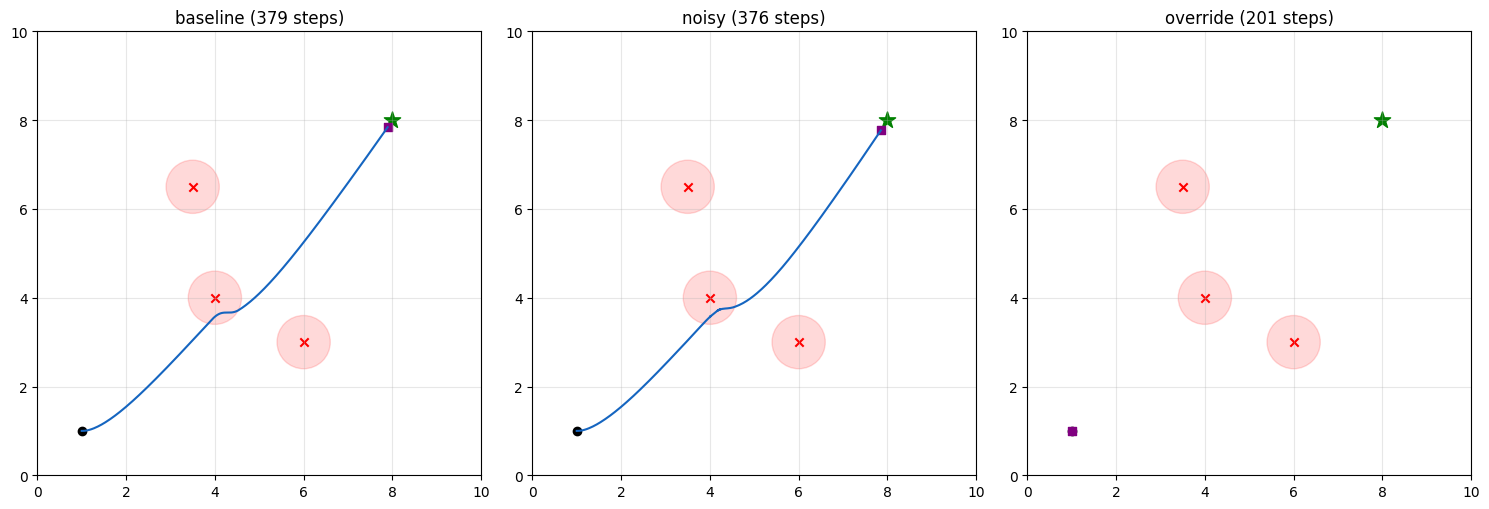

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, traj, title in [
    (axes[0], traj1, f'baseline ({len(traj1)} steps)'),
    (axes[1], traj2, f'noisy ({len(traj2)} steps)'),
    (axes[2], traj3, f'override ({len(traj3)} steps)'),
]:
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.set_aspect('equal')
    for ox, oy in [(4.0, 4.0), (6.0, 3.0), (3.5, 6.5)]:
        ax.add_patch(plt.Circle((ox, oy), 0.6, color='red', alpha=0.15))
        ax.scatter([ox], [oy], c='red', marker='x')
    ax.scatter([8.0], [8.0], c='green', marker='*', s=150)
    xs, ys = zip(*traj)
    ax.plot(xs, ys, color='#1565C0', linewidth=1.5)
    ax.scatter([xs[0]], [ys[0]], c='black', marker='o')
    ax.scatter([xs[-1]], [ys[-1]], c='purple', marker='s')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Take-aways

1. The baseline goal-seek + obstacle repulsion solves a non-trivial path.
2. With noisy perception, the trajectory wiggles but the system still recovers — the safety gate doesn't block because confidence stays above its floor.
3. With human override, the robot does not move at all — the gate is the operator's hard kill switch.
4. None of the perception / decision / controller code changed across runs; we swapped only the perception and the safety configuration. **Each layer is independently testable and replaceable** — this is the practical reason the loop is structured this way.